<a href="https://colab.research.google.com/github/sanya16s/ML_projects/blob/main/Personal_proj2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TITLE: A Smart Grid Failure Prevention Model

## Project Overview:
This project built an end-to-end predictive maintenance system
for electrical grid assets using machine sensor data. The system
combines failure prediction (Random Forest) with asset
segmentation (K-Means) to shift maintenance strategy from
reactive (fix after failure) to proactive (prevent before failure).

Dataset:  AI4I 2020 Predictive Maintenance (10,000 readings)

Industry: Electrical Utilities / Smart Grid Management

Problem:  Equipment failures cause costly unplanned downtime

Solution: Predict failures early + prioritize maintenance tiers


## Phase 1: Foundation

In [1]:
# importing dependencies:

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel, RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Step 1: Data loading & cleaning

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Shape: ", df.shape)
print("No. of rows: ", df.shape[0])
print("No. of columns: ", df.shape[1])

Shape:  (10000, 14)
No. of rows:  10000
No. of columns:  14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print("Total missing: ", df.isnull().sum().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Total missing:  0


In [8]:
print("Columns names: ", df.columns)

Columns names:  Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


In [9]:
df = df.drop(columns = ["UDI", "Product ID"])
print("Columns names: ", df.columns)

Columns names:  Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


In [10]:
# Checking the target column
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [11]:
print("Failure Rate: ", df['Machine failure'].mean()*100, "%")
print("Non-Failure Rate: ", (1-df['Machine failure'].mean())*100, "%")

Failure Rate:  3.39 %
Non-Failure Rate:  96.61 %


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Checking the 5 individual failure types
# Includes Tool wear failure, heat dissipation failure, power failure, overstrain failure, random failure
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Failure types:")
for col in failure_cols:
    print(col, ":", df[col].sum(), "failures")

Failure types:
TWF : 46 failures
HDF : 115 failures
PWF : 95 failures
OSF : 98 failures
RNF : 19 failures


In [14]:
# Keeping the target column and removing the failure_cols
# We are trying to predict failure before it occurs, and failure_cols determine which failure type is happening
df = df.drop(columns = failure_cols)
print("Columns names: ", df.columns)

Columns names:  Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')


In [15]:
print("Shape: ", df.shape)

Shape:  (10000, 7)


In [16]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


In [18]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


### Step 2: Encoding

In [19]:
# Encoding only Type column because model won't work on raw text, it requires numbers
df['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


In [20]:
# Using One-hot encode
# Dropping Type_H, cause if both L and M are 0, it means high quality
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [21]:
df['Type_L'] = df['Type_L'].astype(int)
df['Type_M'] = df['Type_M'].astype(int)

In [22]:
print("Shape: ", df.shape)
print(df.info())

Shape:  (10000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int64  
 6   Type_L                   10000 non-null  int64  
 7   Type_M                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None


In [23]:
var = df[['Type_L', 'Type_M', 'Machine failure']]
num = 1
for col in var:
    print(num, ":", var[col].value_counts())
    num += 1
    print("**"*30)

1 : Type_L
1    6000
0    4000
Name: count, dtype: int64
************************************************************
2 : Type_M
0    7003
1    2997
Name: count, dtype: int64
************************************************************
3 : Machine failure
0    9661
1     339
Name: count, dtype: int64
************************************************************


In [24]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


### Step 3: Exploratory Data Analysis

1. Target Distribution

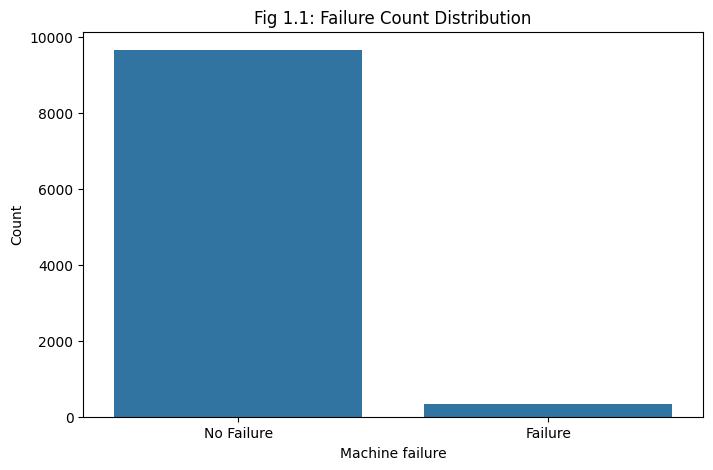

Failure count:  339
Non-Failure count:  9661


In [25]:
# Figure 1.1: Countplot representing the Failure count distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Machine failure')
plt.xlabel('Machine failure')
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.ylabel('Count')
plt.title('Fig 1.1: Failure Count Distribution')
plt.show()
print("Failure count: ", df['Machine failure'].value_counts()[1])
print("Non-Failure count: ", (df['Machine failure'].value_counts()[0]))

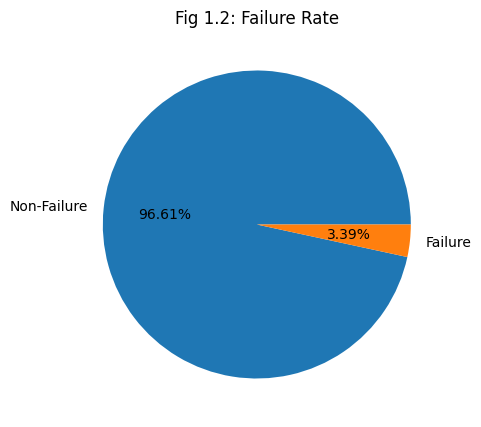

Failure rate:  3.39 %
Non-Failure rate:  96.61 %


In [26]:
# Figure 1.2: Pie chart representing the Failure Rate
plt.figure(figsize=(8,5))
plt.pie(x=df['Machine failure'].value_counts(), labels=['Non-Failure', 'Failure'], autopct='%.2f%%')
plt.title('Fig 1.2: Failure Rate')
plt.show()
print("Failure rate: ", df['Machine failure'].mean()*100, "%")
print("Non-Failure rate: ", (100-df['Machine failure'].mean()*100), "%")

2. Sensor Distributions: Failure vs Non-failure

In [27]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

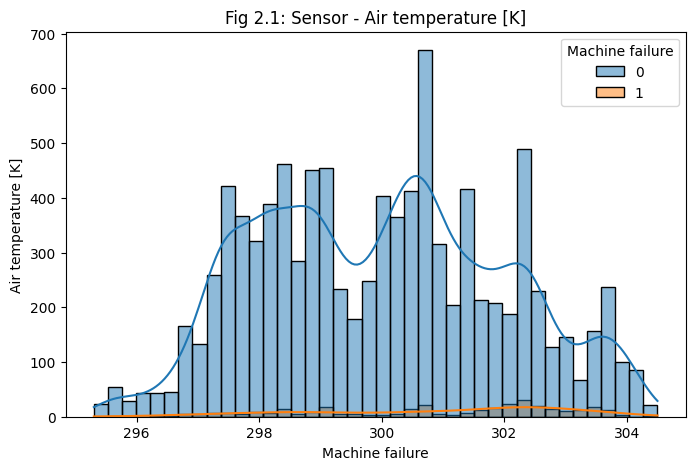

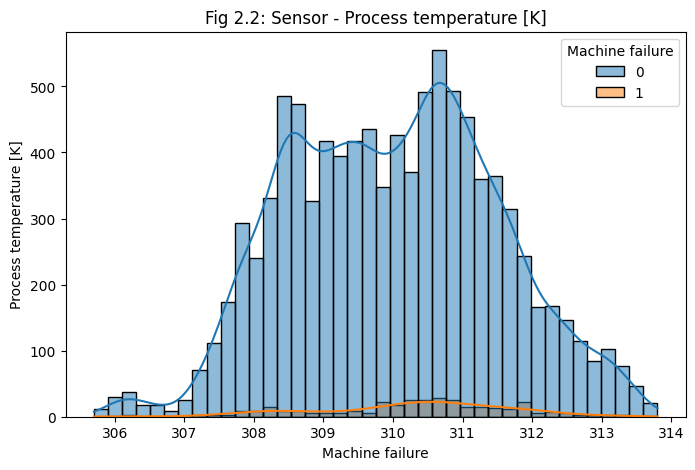

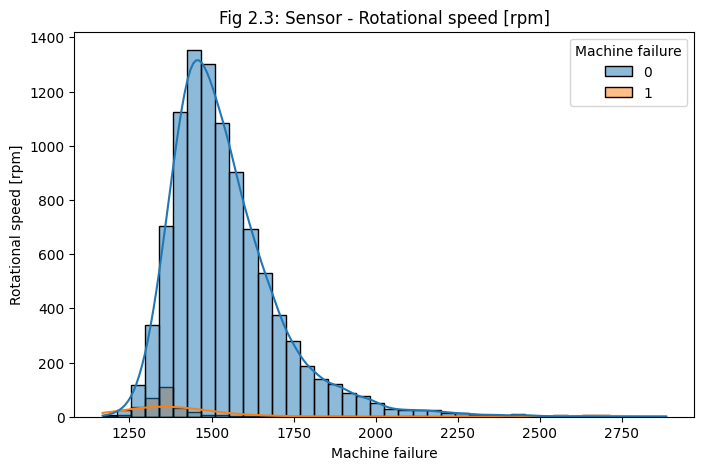

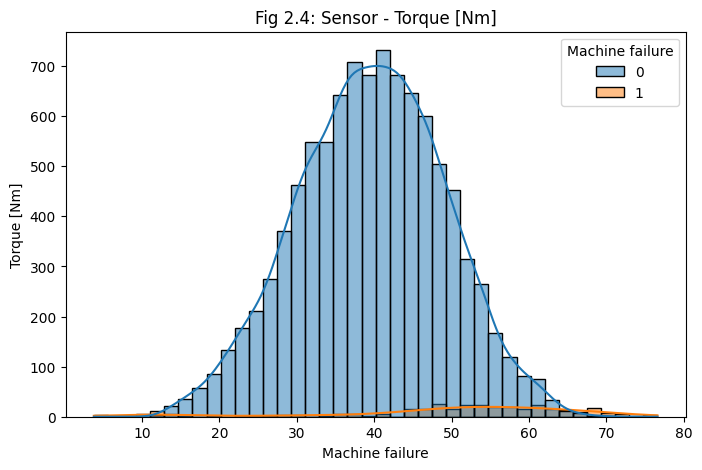

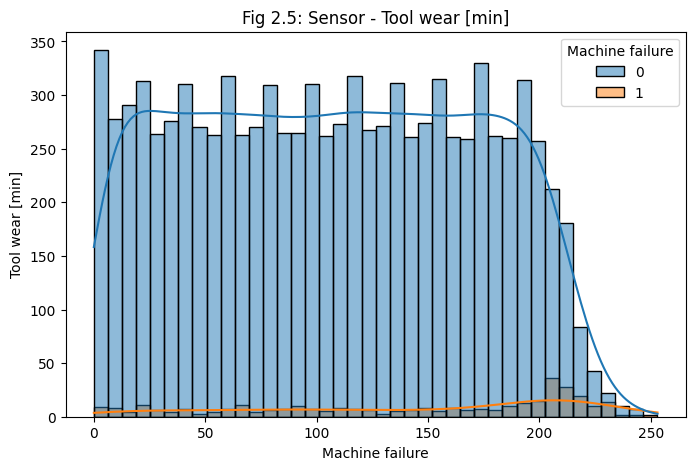

In [28]:
num = 1
for i in sensor_cols:
  plt.figure(figsize=(8,5))
  sns.histplot(data=df, x=i, hue='Machine failure', bins=40, kde=True)
  plt.xlabel('Machine failure')
  plt.ylabel(i)
  plt.title(f'Fig 2.{num}: Sensor - {i}')
  plt.show()
  num +=1

3. Boxplots

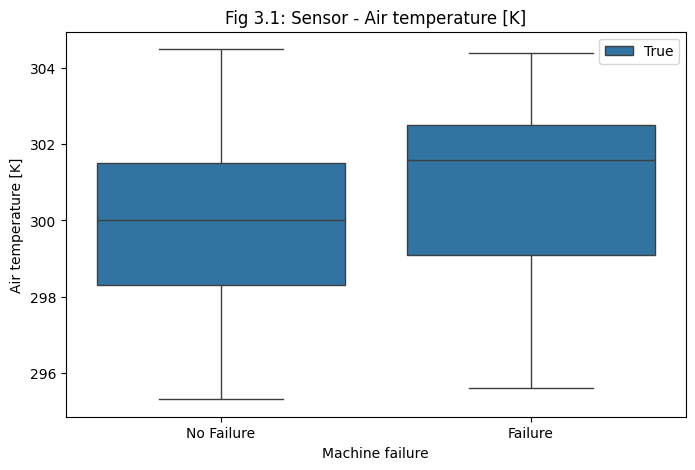

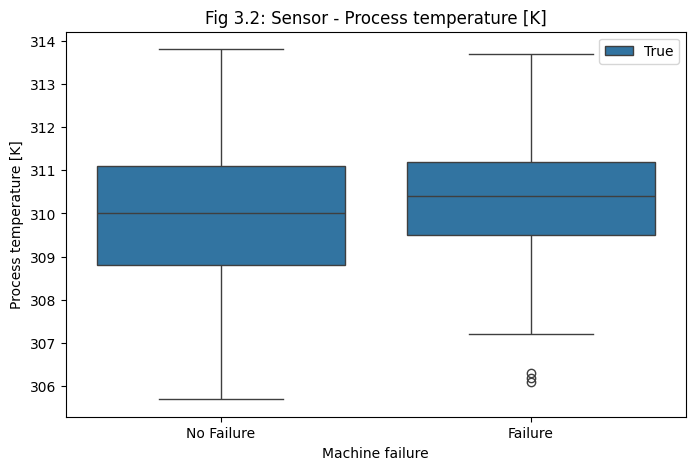

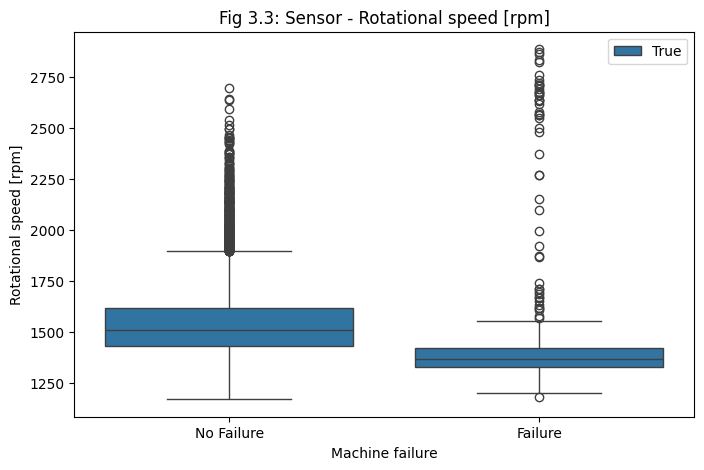

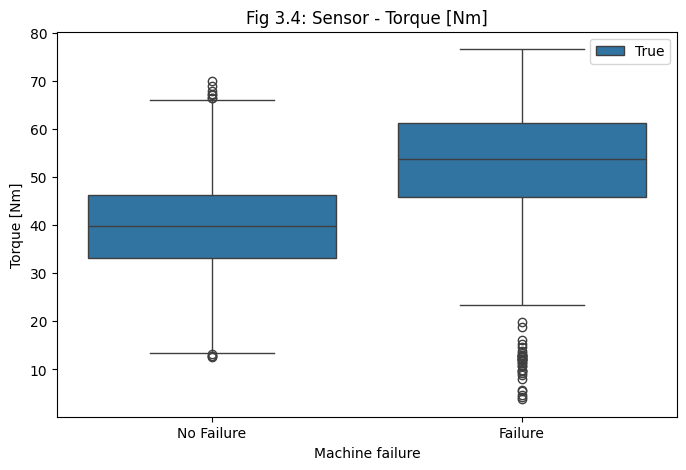

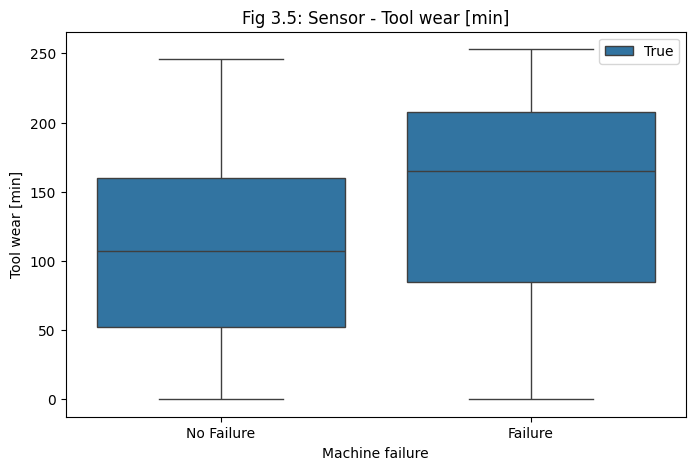

In [29]:
num = 1
for i in sensor_cols:
  plt.figure(figsize=(8,5))
  sns.boxplot(data=df, x='Machine failure', y=i, hue=True)
  plt.title(f'Fig 3.{num}: Sensor - {i}')
  plt.xlabel('Machine failure')
  plt.xticks([0, 1], ['No Failure', 'Failure'])
  plt.ylabel(i)
  plt.show()
  num +=1

4. Correlation Heatmap

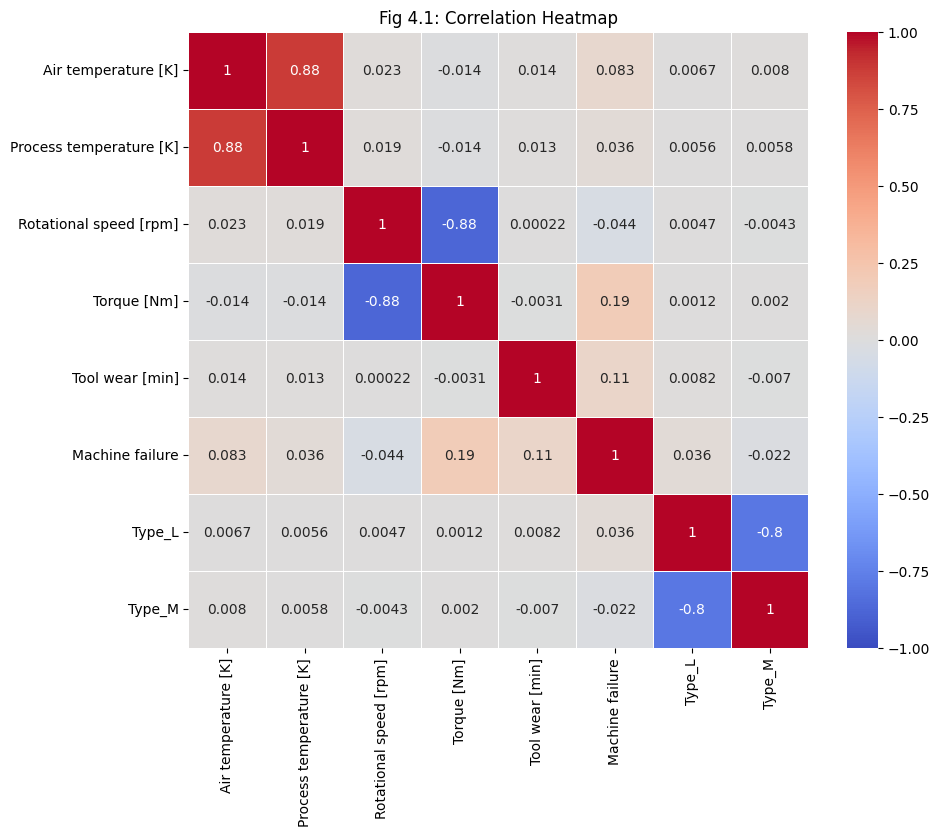

In [30]:
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Fig 4.1: Correlation Heatmap')
plt.show()

5. Failure Rate by Machine Type

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

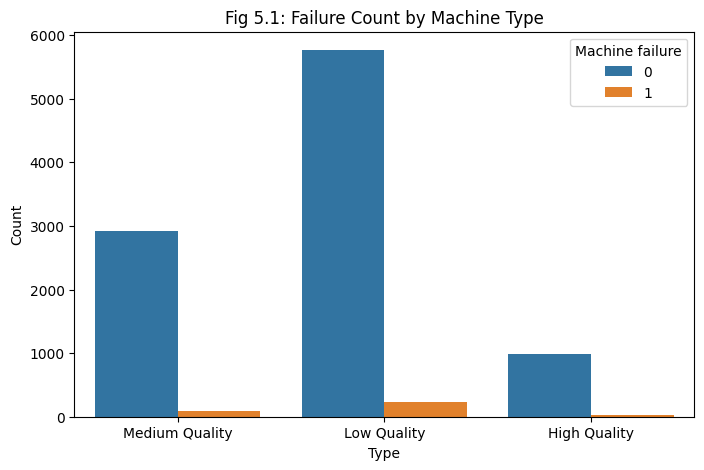

In [31]:
df['Type'] = df.apply(lambda row: 'Low Quality' if row['Type_L'] == 1
                      else 'Medium Quality' if row['Type_M'] == 1
                      else 'High Quality', axis=1)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Type', hue='Machine failure')
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Fig 5.1: Failure Count by Machine Type')
plt

In [32]:
failure_by_type = df.groupby('Type')['Machine failure'].mean() * 100
for machine_type, rate in failure_by_type.items():
    print(f"{machine_type}: {rate:.2f}%")

High Quality: 2.09%
Low Quality: 3.92%
Medium Quality: 2.77%


6. Tool wear vs Torque

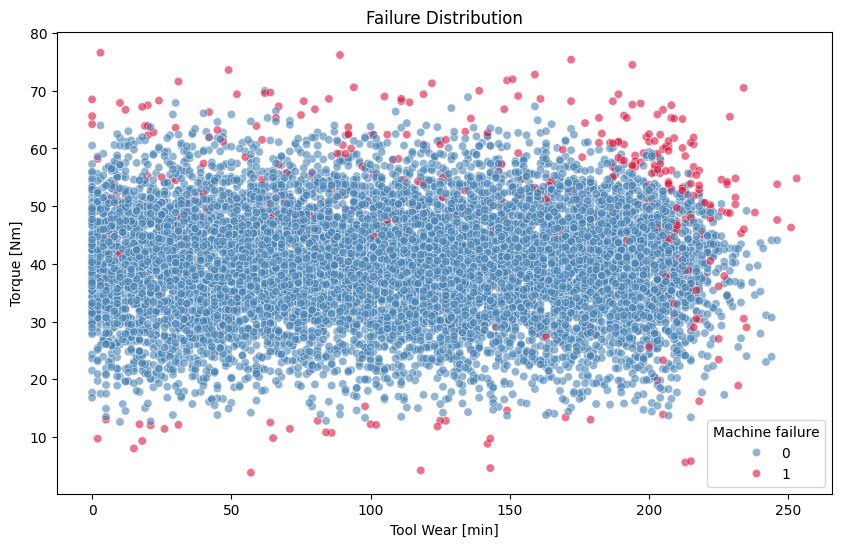

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Tool wear [min]', y='Torque [Nm]', hue='Machine failure', palette=['steelblue', 'crimson'], alpha=0.6)
plt.xlabel('Tool Wear [min]')
plt.ylabel('Torque [Nm]')
plt.title('Failure Distribution')
plt.show()

## Phase 2: Modeling

### Step 4: Feature selection

In [34]:
# Separating the target with other features
X = df.drop(columns=['Machine failure'])
Y = df['Machine failure']

In [35]:
# Encode Type
X = X.drop(columns=['Type'])

In [36]:
print("Feature Matrix shape: ", X.shape)
print("Target Matrix shape: ", Y.shape)
print("Features: ", X.columns)

Feature Matrix shape:  (10000, 7)
Target Matrix shape:  (10000,)
Features:  Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L',
       'Type_M'],
      dtype='object')


In [37]:
# Check multicollinearity using Variance Inflation factor (VIF), ensure all columns are numeric

# Step 1: fit a separate linear regression model for each predictor against all other predictors
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["Features"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_data = vif.sort_values(by='VIF', ascending=False).reset_index(drop=True)
    return vif_data
print ('VIF before feature selection:')
print (calculate_vif(X))

VIF before feature selection:
                  Features           VIF
0  Process temperature [K]  88289.513849
1      Air temperature [K]  87435.495498
2   Rotational speed [rpm]    315.388594
3              Torque [Nm]     72.139059
4                   Type_L      6.986861
5                   Type_M      3.990386
6          Tool wear [min]      3.877508


In [38]:
# Dropping air temperature and rotational speed
cols_to_drop = ['Air temperature [K]', 'Rotational speed [rpm]']
X = X.drop(columns=cols_to_drop)
print ('VIF after feature selection:')
print (calculate_vif(X))
# We should not remove Process temperature (Internal heat matters more) and Torque (tell about speed)

VIF after feature selection:
                  Features        VIF
0  Process temperature [K]  28.819537
1              Torque [Nm]  17.076061
2                   Type_L   6.984314
3                   Type_M   3.989251
4          Tool wear [min]   3.877252


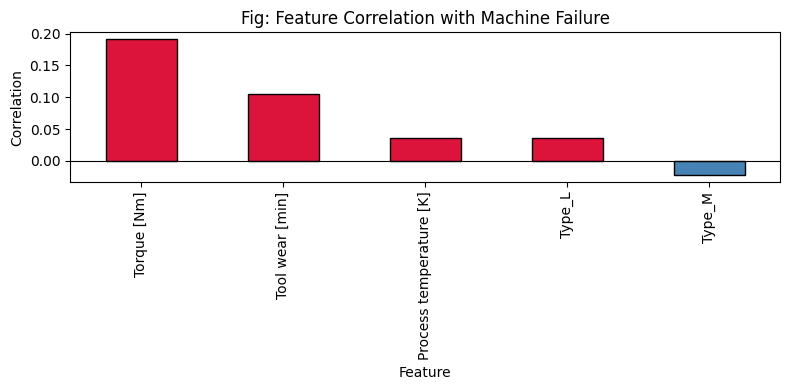

Torque [Nm]                0.191321
Tool wear [min]            0.105448
Process temperature [K]    0.035946
Type_L                     0.035643
Type_M                    -0.022432
dtype: float64


In [39]:
plt.figure(figsize=(8, 4))

feature_corr = X.corrwith(Y).sort_values(ascending=False)
feature_corr.plot(kind='bar', color=['crimson' if v > 0 else 'steelblue' for v in feature_corr], edgecolor='black')

plt.title('Fig: Feature Correlation with Machine Failure')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(feature_corr)

### Step 5: Train-test-split

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print ("Shape of X_train: ", X_train.shape)
print ("Shape of X_test: ", X_test.shape)
print ("Shape of Y_train: ", Y_train.shape)
print ("Shape of Y_test: ", Y_test.shape)
print ("Training failure rate: {:.2f}%".format(Y_train.mean()*100))
print ("Testing failure rate: {:.2f}%".format(Y_test.mean()*100))

Shape of X_train:  (8000, 5)
Shape of X_test:  (2000, 5)
Shape of Y_train:  (8000,)
Shape of Y_test:  (2000,)
Training failure rate: 3.39%
Testing failure rate: 3.40%


In [41]:
print("SPLIT SUMMARY:")
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print("-"*45)
print(f"Training failures: {Y_train.sum()} ({Y_train.mean()*100:.2f}%)")
print(f"Test failures: {Y_test.sum()} ({Y_test.mean()*100:.2f}%)")
print("*"*45)

SPLIT SUMMARY:
Total samples: 10000
Training samples: 8000 (80%)
Test samples: 2000 (20%)
---------------------------------------------
Training failures: 271 (3.39%)
Test failures: 68 (3.40%)
*********************************************


### Step 6: Random Forest and Recall Optimization

In [42]:
# Building a baseline Random Forest classifier
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, Y_train)

Y_pred_baseline = rf_baseline.predict(X_test)

print("Baseline Model Performance:")
print(classification_report(Y_test, Y_pred_baseline, target_names=['No Failure', 'Failure']))

Baseline Model Performance:
              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1932
     Failure       0.84      0.38      0.53        68

    accuracy                           0.98      2000
   macro avg       0.91      0.69      0.76      2000
weighted avg       0.97      0.98      0.97      2000



Note: Even though the accuracy is 98%, recall for Failure is 38%, meaning that the model misses most actual failures. To solve this we need to perform Recall Optimization.

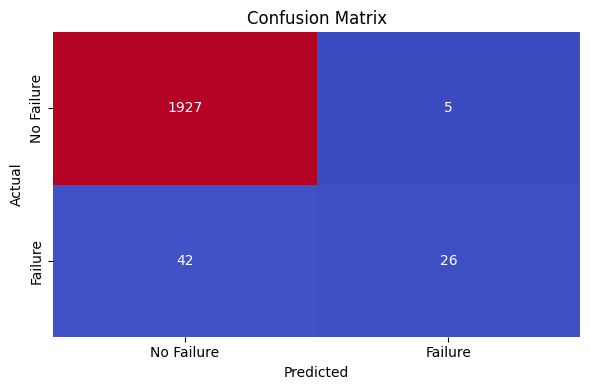

In [43]:
# Confusion Matrix of the baseline model
cm = confusion_matrix(Y_test, Y_pred_baseline)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False, xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [44]:
tn, fp, fn, tp = cm.ravel()
print("True Negatives: ", tn)
print("False Positives: ", fp)
print("False Negatives: ", fn)
print("True Positives: ", tp)
print(f"Recall (baseline): {tp/(tp+fn)*100:.1f}% of actual failures caught")

True Negatives:  1927
False Positives:  5
False Negatives:  42
True Positives:  26
Recall (baseline): 38.2% of actual failures caught


*   **True Negative** - Correctly said No failure
*   **False Positive** - Detected failure, during no failure condition
*   **False Negative** - Detected no failure, during failure condition. *(Very Dangerous)*
*   **True Positive** - Correctly said failure

**NOTE**: Recall matters more than Accuracy because during False Negative, possibility of blackout, equipment damage, etc occurs.

In [45]:
# Parameter Tuning with GridSearchCV (Recall optimization)
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2,5,10],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=1)
grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'class_weight': ['balanced', None],
                         'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=1)

In [46]:
print("Best Parameter found: ")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\n Best cross-validation score: {grid_search.best_score_*100:.2f}%")

Best Parameter found: 
class_weight: balanced
max_depth: 10
min_samples_split: 10
n_estimators: 200

 Best cross-validation score: 57.60%


In [47]:
# Using GridSearch to obtain the best model
rf_tuned = grid_search.best_estimator_
Y_pred_tuned = rf_tuned.predict(X_test)

print("Tuned Model Performance:")
print(classification_report(Y_test, Y_pred_tuned, target_names=['No Failure', 'Failure']))

Tuned Model Performance:
              precision    recall  f1-score   support

  No Failure       0.98      0.96      0.97      1932
     Failure       0.32      0.51      0.40        68

    accuracy                           0.95      2000
   macro avg       0.65      0.74      0.69      2000
weighted avg       0.96      0.95      0.95      2000



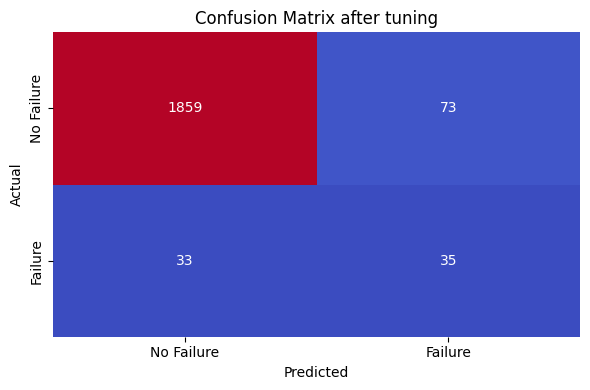

In [48]:
# Confusion Matrix of the tuned model
cm_tuned = confusion_matrix(Y_test, Y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='coolwarm', cbar=False, xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after tuning')
plt.tight_layout()
plt.show()

In [49]:
tn, fp, fn, tp = cm_tuned.ravel()
print("True Negatives: ", tn)
print("False Positives: ", fp)
print("False Negatives: ", fn)
print("True Positives: ", tp)
print(f"Baseline recall: {recall_score(Y_test, Y_pred_baseline)*100:.1f}%")
print(f"Tuned recall: {recall_score(Y_test, Y_pred_tuned)*100:.1f}%")

True Negatives:  1859
False Positives:  73
False Negatives:  33
True Positives:  35
Baseline recall: 38.2%
Tuned recall: 51.5%


As we can observe that the tuned recall improved. In this, the Failure missed (False Negatives) is lower than the baseline False negative value.

### Step 7: Feature Importance

In [50]:
# To determine feature importance
feature_importance = pd.DataFrame({'Feature':X.columns, 'Importance': rf_tuned.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("Feature Importance Ranking: ")
print(feature_importance)

Feature Importance Ranking: 
                   Feature  Importance
1              Torque [Nm]    0.593731
2          Tool wear [min]    0.254989
0  Process temperature [K]    0.131728
3                   Type_L    0.011920
4                   Type_M    0.007632


In feature importance, Torque and Tool wear are the top 2 most important features similar to what we observed in correlation analysis.

In [51]:
# Since both 2 features are almost of 0 importance, we can drop them
X_selected = X.drop(['Type_L', 'Type_M'], axis=1)

In [52]:
# Again splitting after dropping the bottom 2 features
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(X_selected, Y, test_size=0.2, random_state=42)

In [53]:
# Retrain the model
rf_selected = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
Y_pred_selected = rf_selected.predict(X_test_sel)

print("Tuned Model Performance:")
print(classification_report(Y_test_sel, Y_pred_selected, target_names=['No Failure', 'Failure']))
print(f"Final recall: {recall_score(Y_test_sel, Y_pred_selected)*100:.1f}%")

Tuned Model Performance:
              precision    recall  f1-score   support

  No Failure       0.98      0.95      0.97      1939
     Failure       0.23      0.44      0.31        61

    accuracy                           0.94      2000
   macro avg       0.61      0.70      0.64      2000
weighted avg       0.96      0.94      0.95      2000

Final recall: 44.3%


**Key Observations:**
*   Baseline Recall score (38.2%) means that about 62% failures were missed.
*   Tuned Recall score (50%) means that GridSearchCV improved it and the model caught 1 in 2 failures.
*   Final Recall score (44.3%) was found after dropping the "Type_L" and "Type_M" columns.

**FINAL DECISION**: We should keep all 5 features and use the tuned model (50% recall) as our final model. Reasons include:


*   Final recall score is less than the Tuned recall score, which shows that the dropped features contributed meaningful information.
*   Tuned model caught about 34 failures which is 8 more failures than the baseline model. Practically, this can save multiple emergency repairs.





### Step 8: Cross-validation and ROC-AUC score

In [54]:
# Running cross validation with best parameters
rf_cv = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced', min_samples_split=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Checking accuracy
cv_accuracy = cross_val_score(rf_cv, X, Y, cv=5, scoring='accuracy')
print(cv_accuracy)
print("Accuracy: ", cv_accuracy.mean())

[0.9645 0.954  0.929  0.884  0.96  ]
Accuracy:  0.9382999999999999


In [55]:
# Checking recall
cv_recall = cross_val_score(rf_cv, X, Y, cv=skf, scoring='recall')
print(cv_recall)
print("Recall: ", cv_recall.mean()*100, "%")

[0.58208955 0.54411765 0.57352941 0.61764706 0.57352941]
Recall:  57.8182616330114 %


In [ ]:
# ROC
cv_roc_auc = cross_val_score(rf_cv, X, Y, cv=skf, scoring='roc_auc')
print(cv_roc_auc)
print("ROC AUC: ", cv_roc_auc.mean())

In [57]:
Y_prob = rf_tuned.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
auc_score = roc_auc_score(Y_test, Y_prob)
print ('AUC Score:', auc_score*100, "%")

AUC Score: 90.5446961393253 %


In [ ]:
# Plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0,1], [0,1], linestyle='--')
plt.plot([0,1], [0.5,0.5], linestyle='dashdot')
plt.fill_between(fpr, tpr, alpha=0.1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Fig 8.1: Smart Grid Failure Prediction')
plt.legend(loc='lower right')
plt.show()

**NOTE**: When we consider default threshold as 0.5 (green dasheddot line), anything above 0.5 gets flagged as failure, while anything below doesn't. We can move it as per needed just like a security alarm sensitivity dial. In power grid, a missed failure causes blackout which leads to lakhs lost. An unncessary maintenance check causes small cost.

If less threshold, then more percentage of failures will be detected including more false alarms. This can lead to maintenance visit, which cause less damage and avoids blackout.

Hence, it is better to keep an optimal lower threshold to catch as many failures as possible.

In [ ]:
# To go through every threshold possible, and calculate recall and false alarm rate
recall_scores = []
false_alarm_rates = []

for threshold in thresholds:
  # If the machine's failure probability is greater than or equal to this threshold, call it a failure (1), otherwise call it fine (0)
  Y_pred_thresh = (Y_prob >= threshold).astype(int)
  tp = ((Y_pred_thresh == 1) & (Y_test == 1)).sum() #Caught real failures
  tn = ((Y_pred_thresh == 0) & (Y_test == 0)).sum() #Correctly said fine
  fp = ((Y_pred_thresh == 1) & (Y_test == 0)).sum() #False alarms
  fn = ((Y_pred_thresh == 0) & (Y_test == 1)).sum() #MIssed real failures
  recall = tp / (tp + fn)
  false_alarm_rate = fp / (fp + tn)
  recall_scores.append(recall)
  false_alarm_rates.append(false_alarm_rate)

In [ ]:
# To find the one with the fewest false alarms from all threshold of atleast 70% recall

target_recall = 0.70
valid = [(f, r, t) for f, r, t in
         zip(false_alarm_rates, recall_scores, thresholds) if r >= target_recall]

# To get the best fpr, recall, threshold
best_fpr, best_recall, best_threshold = min(valid, key=lambda x: x[0])
print(f"Best FPR: {best_fpr*100:.4f}%")
print(f"Best Recall: {best_recall*100:.4f}%")
print(f"Best Threshold: {best_threshold*100:.4f}%")

**Observations from the above results**:  

*   Only 8.6% of healthy machines get falsely flagged.
*   Out of every 100 real failures, we now catch about 73.
*   We achieved this by lowering the decision point (optimal threshold) from 50% to 35.85%

**Key insights:**

* Switching the optimal threshold to 0.358 can reduce unplanned downtime by catching 73.5% of failures before they occur.
* Extra failures caught is about 16 per test cycle, where 16 transformer failures can be prevented.
* Each transformer failure cost ranging from Rs. 40k to over 1 crore depending on the size, in emergency repairs and downtime.
* Comparatively maintenance checks costs a fraction of that.



**Expenditure and Savings**:

* Extra failures caught = ~16 additional failures
* Each prevented failure = Rs. 40k to 1 crore savings
* Extra false alarms = ~166 unnecessary checks
* Cost of false alarms = ~10

-> Conservative estimate:

16 x each prevented failure = 6.4 lakh to 16 crore

## Phase 3: Segmentation and Insights

### Step 9: K-Means Clustering on Healthy Assets

In [61]:
# Isolate healthy machines and to ensure the original df is not affected we use copy()

healthy_machines = df['Machine failure'] == 0
df_healthy = df[healthy_machines].copy()
df_healthy.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M,Type
0,298.1,308.6,1551,42.8,0,0,0,1,Medium Quality
1,298.2,308.7,1408,46.3,3,0,1,0,Low Quality
2,298.1,308.5,1498,49.4,5,0,1,0,Low Quality
3,298.2,308.6,1433,39.5,7,0,1,0,Low Quality
4,298.2,308.7,1408,40.0,9,0,1,0,Low Quality


In [62]:
# Using same features as we did for feature importance
cluster_features = ['Process temperature [K]', 'Torque [Nm]', 'Tool wear [min]']
X_cluster = df_healthy[cluster_features].copy()
X_cluster.head()

,Process temperature [K],Torque [Nm],Tool wear [min]
0,308.6,42.8,0
1,308.7,46.3,3
2,308.5,49.4,5
3,308.6,39.5,7
4,308.7,40.0,9


In [63]:
X_cluster.describe()

,Process temperature [K],Torque [Nm],Tool wear [min]
count,9661.000000,9661.000000,9661.000000
mean,309.995570,39.629655,106.693717
std,1.486846,9.472080,62.945790
min,305.700000,12.600000,0.000000
25%,308.800000,33.100000,52.000000
50%,310.000000,39.900000,107.000000
75%,311.100000,46.300000,160.000000
max,313.800000,70.000000,246.000000


In [64]:
# Records
print("Total machines:", len(df))
print("Healthy machines:", len(df_healthy))
print("Percentage of healthy machines:", len(df_healthy)/len(df)*100, "%")
print("Failed machines:", len(df)-len(df_healthy))
print("Percentage of failed machines:", (len(df)-len(df_healthy))/len(df)*100, "%")
print("Clustering features:", cluster_features)
print("No. of rows in Clustering features:", X_cluster.shape[0])
print("No. of columns in Clustering features:", X_cluster.shape[1])

Total machines: 10000
Healthy machines: 9661
Percentage of healthy machines: 96.61 %
Failed machines: 339
Percentage of failed machines: 3.39 %
Clustering features: ['Process temperature [K]', 'Torque [Nm]', 'Tool wear [min]']
No. of rows in Clustering features: 9661
No. of columns in Clustering features: 3


In [65]:
# Asset segmentation and making all features on the same scale (mean=0, std=1)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

X_cluster_scaled = pd.DataFrame(X_cluster_scaled, columns=cluster_features, index=X_cluster.index)
X_cluster_scaled.head()

,Process temperature [K],Torque [Nm],Tool wear [min]
0,-0.938659,0.334721,-1.695097
1,-0.871399,0.704248,-1.647435
2,-1.005919,1.031542,-1.615660
3,-0.938659,-0.013689,-1.583885
4,-0.871399,0.039101,-1.552110


In [66]:
# Reason for scaling: Since KMeans uses distance therefore, unscaled features with bigger ranges dominate unfairly
# Comparing before and after scaling results

print("Before scaling:")
print(X_cluster.describe().loc[['min', 'max']])
print("\nAfter scaling:")
print(X_cluster_scaled.describe().loc[['min', 'max']].round(3))

Before scaling:
     Process temperature [K]  Torque [Nm]  Tool wear [min]
min                    305.7         12.6              0.0
max                    313.8         70.0            246.0

After scaling:
     Process temperature [K]  Torque [Nm]  Tool wear [min]
min                   -2.889       -2.854           -1.695
max                    2.559        3.206            2.213


In [67]:
# Finding optimal K by using Elbow method
# In this, we find where adding more clusters stops being useful
wcss = [] #Within-Cluster Sum of Squares
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)
    print(f"WCSS for k={k}: {wcss[-1]:.2f}")

WCSS for k=2: 21749.27
WCSS for k=3: 17587.99
WCSS for k=4: 14314.23
WCSS for k=5: 12316.94
WCSS for k=6: 10628.93
WCSS for k=7: 9623.38
WCSS for k=8: 8744.92
WCSS for k=9: 8210.39
WCSS for k=10: 7734.39


In [ ]:
# Finding optimal K by using Silhouette Score
# In this, we measure how cleanly separated the clusters are
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    labels = kmeans.labels_ #forms an array
    silhouette_avg = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Silhouette Score for k={k}: {silhouette_scores[-1]:.4f}")

In [69]:
best_k_silhouette = silhouette_scores.index(max(silhouette_scores)) + 2
# Added 2 because our range started from 2 and not 0
print ("Best K by silhoutte score:", best_k_silhouette)

Best K by silhoutte score: 6


**K Selection final decision:**

K=6 is mathematically optimal but operationally impractical as no utility company manages 6 tiers. Since, Silhouette scores are nearly identical (0.23-0.26) meaning K=3 and K=6 perform similarly.

Also, Industry standard is 3 tiers (Low, Medium, High) for maintenance scheduling. Therefore, domain knowledge overrides marginal math difference.

Final Optimal K = 3

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
optimal_k = 3
k_range = range(2,11)
# Elbow plot
axes[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8, markerfacecolor='crimson')
optimal_idx = optimal_k - 2
# Highlight best K
axes[0].scatter(optimal_k, wcss[optimal_idx], color='crimson', marker='o', s=200, zorder=5)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method for Finding Optimal K')
axes[0].grid(True, alpha=0.3)

# Annotatinge each point
for k, inertia in zip(k_range, wcss):
    axes[0].annotate(f'K={k}', (k, inertia), textcoords='offset points', xytext=(0, 10), ha='center')

# Silhouette Plot
colors = ['crimson' if s == max(silhouette_scores)
          else 'steelblue' for s in silhouette_scores]

bars = axes[1].bar(k_range, silhouette_scores, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Higher is Better')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, silhouette_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center')

# Highlight best K
axes[1].annotate(f'Best K={optimal_k}', (optimal_k, silhouette_scores[optimal_idx]),
                 textcoords='offset points', xytext=(0, 20), ha='center',
                color='crimson', fontweight='bold')

plt.suptitle('Fig 9.1: Optimal K Selection — Elbow + Silhouette')
plt.tight_layout()
plt.show()

In [ ]:
# Applying final KMeans
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_healthy['Cluster'] = final_kmeans.fit_predict(X_cluster_scaled)

In [ ]:
cluster_counts = df_healthy['Cluster'].value_counts().sort_index()

for cluster_id, count in cluster_counts.items():
    machine_percent = count/len(df_healthy)*100
    print(f"Cluster {cluster_id}: {count} machines ({machine_percent:.2f}%)")
#

In [ ]:
# Calculate average sensor readings per cluster
# This tells us WHAT each cluster represents
cluster_profile = df_healthy.groupby('Cluster')[cluster_features].mean().round(2)

print("Average Sensor Readings:")
print(cluster_profile)

In [74]:
tier_labels= {
    0:'Low Risk',
    1:'Medium Risk',
    2:'High Risk'
}

In [ ]:
# Step 3 — Assign tier labels

df_healthy['Maintenance Tier'] = df_healthy['Cluster'].map(tier_labels)

print("Machines per maintenance tier:")
print(df_healthy['Maintenance Tier'].value_counts())

In [76]:
df_healthy.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M,Type,Cluster,Maintenance Tier
0,298.1,308.6,1551,42.8,0,0,0,1,Medium Quality,0,Low Risk
1,298.2,308.7,1408,46.3,3,0,1,0,Low Quality,0,Low Risk
2,298.1,308.5,1498,49.4,5,0,1,0,Low Quality,0,Low Risk
3,298.2,308.6,1433,39.5,7,0,1,0,Low Quality,0,Low Risk
4,298.2,308.7,1408,40.0,9,0,1,0,Low Quality,0,Low Risk


In [77]:
tier_colors = {
    'Low Risk':    '#2ecc71',
    'Medium Risk': '#f39c12',
    'High Risk':   '#e74c3c'
}

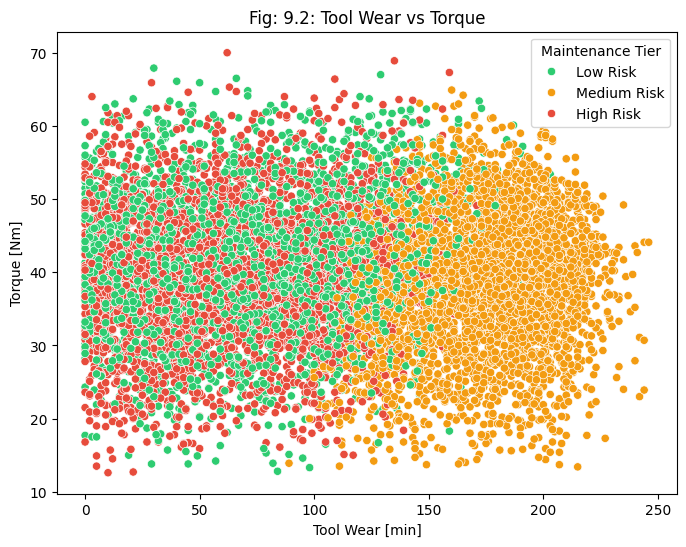

In [78]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_healthy , x='Tool wear [min]', y='Torque [Nm]', hue='Maintenance Tier', palette=tier_colors)
plt.title("Fig: 9.2: Tool Wear vs Torque")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Torque [Nm]")
plt.legend(title='Maintenance Tier')
plt.show()

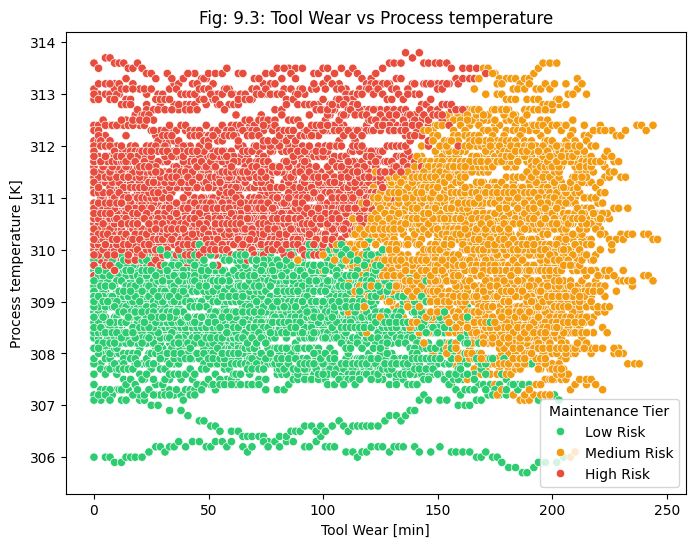

In [79]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_healthy , x='Tool wear [min]', y='Process temperature [K]', hue='Maintenance Tier', palette=tier_colors)
plt.title("Fig: 9.3: Tool Wear vs Process temperature")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Process temperature [K]")
plt.legend(title='Maintenance Tier')
plt.show()

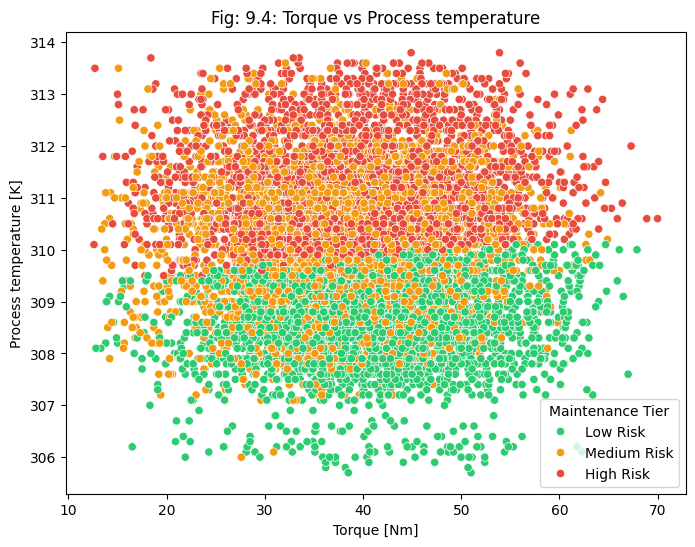

In [80]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_healthy , x='Torque [Nm]', y='Process temperature [K]', hue='Maintenance Tier', palette=tier_colors)
plt.title("Fig: 9.4: Torque vs Process temperature")
plt.xlabel("Torque [Nm]")
plt.ylabel("Process temperature [K]")
plt.legend(title='Maintenance Tier')
plt.show()

**CLUSTER VISUALIZATION OBSERVATIONS**

1. Tool Wear vs Torque:

    * Medium Risk (orange) clearly isolated at high tool wear (150-250 min) machines running longest
    * Low/High Risk overlap in low wear zone

2. Tool Wear vs Temperature (BEST PLOT):

    * High Risk (red) sits at high temperature (311-314K)
    * Low Risk (green) sits at low temperature (306-310K)
    * Clear horizontal band separation

3. Torque vs Temperature:

    * Temperature again drives separation
    * High temp = High Risk regardless of torque level


**Key Findings**:

    * Process Temperature is the PRIMARY clustering driver
    * Tool Wear is the SECONDARY clustering driver
    * Torque alone does not cleanly separate risk groups

In [81]:
cluster_profile['Maintenance Tier'] = cluster_profile.index.map(tier_labels)
cluster_profile

,Process temperature [K],Torque [Nm],Tool wear [min],Maintenance Tier
Cluster,,,,
0,308.56,41.37,74.97,Low Risk
1,310.15,38.06,172.84,Medium Risk
2,311.24,39.68,63.02,High Risk


### Step 10: Visualizations

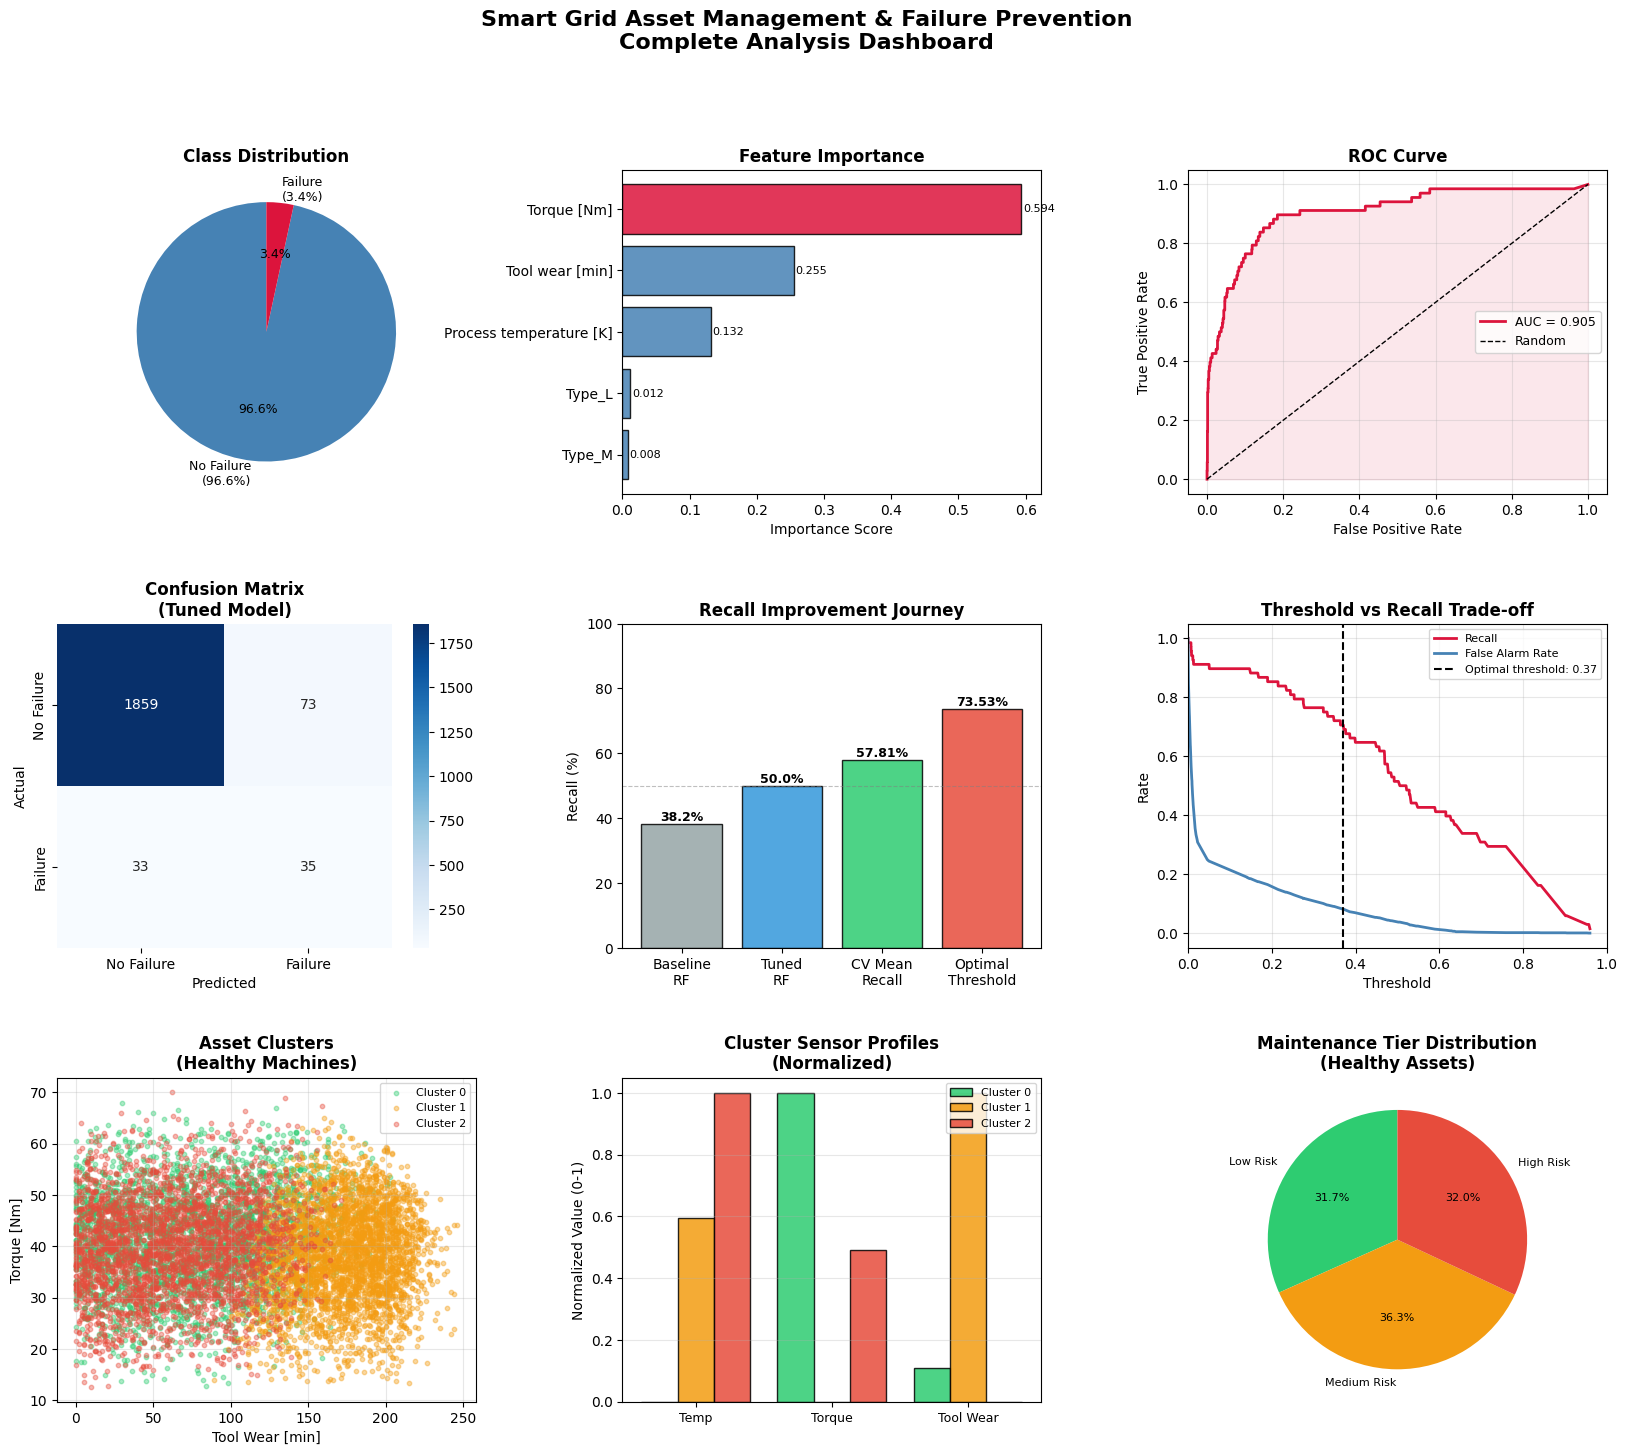

In [82]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Smart Grid Asset Management & Failure Prevention\nComplete Analysis Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# ── Define grid layout ──────────────────────────────────
# 3 rows, 3 columns
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])      # Class distribution
ax2 = fig.add_subplot(gs[0, 1])      # Feature importance
ax3 = fig.add_subplot(gs[0, 2])      # ROC curve
ax4 = fig.add_subplot(gs[1, 0])      # Confusion matrix
ax5 = fig.add_subplot(gs[1, 1])      # Model comparison
ax6 = fig.add_subplot(gs[1, 2])      # Threshold analysis
ax7 = fig.add_subplot(gs[2, 0])      # Cluster scatter
ax8 = fig.add_subplot(gs[2, 1])      # Cluster profiles
ax9 = fig.add_subplot(gs[2, 2])      # Maintenance tier summary

# ── Plot 1: Class Distribution ───────────────────────────
failure_counts = df['Machine failure'].value_counts()
ax1.pie(failure_counts,
        labels=['No Failure\n(96.6%)', 'Failure\n(3.4%)'],
        colors=['steelblue', 'crimson'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9})
ax1.set_title('Class Distribution', fontweight='bold')

# ── Plot 2: Feature Importance ───────────────────────────
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=True)

colors_imp = ['crimson' if i >= feat_imp['Importance'].max() * 0.8
              else 'steelblue' for i in feat_imp['Importance']]

ax2.barh(feat_imp['Feature'], feat_imp['Importance'],
         color=colors_imp, edgecolor='black', alpha=0.85)
ax2.set_title('Feature Importance', fontweight='bold')
ax2.set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(feat_imp['Importance'],
                                     feat_imp['Feature'])):
    ax2.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

# ── Plot 3: ROC Curve ─────────────────────────────────────
ax3.plot(fpr, tpr, color='crimson', linewidth=2,
         label=f'AUC = {auc_score:.3f}')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax3.fill_between(fpr, tpr, alpha=0.1, color='crimson')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── Plot 4: Confusion Matrix (Tuned Model) ────────────────
cm_tuned = confusion_matrix(Y_test, Y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d',
            cmap='Blues', ax=ax4,
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'],
            annot_kws={'size': 10})
ax4.set_title('Confusion Matrix\n(Tuned Model)', fontweight='bold')
ax4.set_ylabel('Actual')
ax4.set_xlabel('Predicted')

# ── Plot 5: Model Performance Comparison ──────────────────
models = ['Baseline\nRF', 'Tuned\nRF', 'CV Mean\nRecall',
          'Optimal\nThreshold']
recalls = [38.2, 50.0, 57.81, 73.53]
bar_colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']

bars = ax5.bar(models, recalls, color=bar_colors,
               edgecolor='black', alpha=0.85)
ax5.set_ylabel('Recall (%)')
ax5.set_title('Recall Improvement Journey', fontweight='bold')
ax5.set_ylim(0, 100)
ax5.axhline(50, color='gray', linestyle='--',
            linewidth=0.8, alpha=0.5)

for bar, val in zip(bars, recalls):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val}%', ha='center',
             fontsize=9, fontweight='bold')

# ── Plot 6: Threshold vs Recall Trade-off ─────────────────
ax6.plot(thresholds, recall_scores,
         color='crimson', linewidth=2, label='Recall')
ax6.plot(thresholds, false_alarm_rates,
         color='steelblue', linewidth=2, label='False Alarm Rate')
ax6.axvline(best_threshold, color='black',
            linestyle='--', linewidth=1.5,
            label=f'Optimal threshold: {best_threshold:.2f}')
ax6.set_xlabel('Threshold')
ax6.set_ylabel('Rate')
ax6.set_title('Threshold vs Recall Trade-off', fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.set_xlim(0, 1)

# ── Plot 7: Cluster Scatter ───────────────────────────────
cluster_colors = ['#2ecc71', '#f39c12', '#e74c3c',
                  '#3498db', '#9b59b6'][:optimal_k]

for cluster_id in range(optimal_k):
    mask = df_healthy['Cluster'] == cluster_id
    ax7.scatter(
        df_healthy[mask]['Tool wear [min]'],
        df_healthy[mask]['Torque [Nm]'],
        c=cluster_colors[cluster_id],
        alpha=0.4, s=10,
        label=f'Cluster {cluster_id}'
    )

ax7.set_xlabel('Tool Wear [min]')
ax7.set_ylabel('Torque [Nm]')
ax7.set_title('Asset Clusters\n(Healthy Machines)', fontweight='bold')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# ── Plot 8: Cluster Average Profiles ─────────────────────
profile_cols = ['Process temperature [K]',
                'Torque [Nm]', 'Tool wear [min]']
cluster_means = df_healthy.groupby('Cluster')[profile_cols].mean()

x_pos = np.arange(len(profile_cols))
width = 0.8 / optimal_k

for i, cluster_id in enumerate(cluster_means.index):
    # Normalize each metric to 0-1 for fair comparison
    normalized = (cluster_means.loc[cluster_id] -
                  cluster_means.min()) / \
                 (cluster_means.max() - cluster_means.min())
    ax8.bar(x_pos + i * width, normalized,
            width=width,
            color=cluster_colors[i],
            label=f'Cluster {cluster_id}',
            edgecolor='black', alpha=0.85)

ax8.set_xticks(x_pos + width * (optimal_k - 1) / 2)
ax8.set_xticklabels(['Temp', 'Torque', 'Tool Wear'],
                     fontsize=9)
ax8.set_ylabel('Normalized Value (0-1)')
ax8.set_title('Cluster Sensor Profiles\n(Normalized)', fontweight='bold')
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3, axis='y')

# ── Plot 9: Maintenance Tier Recommendation ───────────────
tier_labels = cluster_profile['Maintenance Tier'].values
tier_counts = [df_healthy[df_healthy['Cluster'] == i].shape[0]
               for i in cluster_profile.index]
tier_colors_pie = ['#2ecc71', '#f39c12', '#e74c3c'][:optimal_k]

wedges, texts, autotexts = ax9.pie(
    tier_counts,
    labels=tier_labels,
    colors=tier_colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 8}
)
ax9.set_title('Maintenance Tier Distribution\n(Healthy Assets)',
              fontweight='bold')

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sensor_pairs = [
    ('Tool wear [min]', 'Torque [Nm]'),
    ('Tool wear [min]', 'Process temperature [K]'),
    ('Torque [Nm]', 'Process temperature [K]')
]

for ax, (x_feat, y_feat) in zip(axes, sensor_pairs):
    # Healthy machines
    ax.scatter(df_healthy[x_feat], df_healthy[y_feat],
               c='steelblue', alpha=0.2, s=8,
               label='Healthy')
    # Failed machines
    failed = df[df['Machine failure'] == 1]
    ax.scatter(failed[x_feat], failed[y_feat],
               c='crimson', alpha=0.7, s=20,
               label='Failed', zorder=5)

    ax.set_xlabel(x_feat, fontsize=10)
    ax.set_ylabel(y_feat, fontsize=10)
    ax.set_title(f'{x_feat.split("[")[0].strip()} vs\n'
                 f'{y_feat.split("[")[0].strip()}',
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sensor Relationships — Healthy vs Failed Machines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [84]:
# Final business-facing output
schedule = {
    'Low Risk': ('Every 6 months', 'Routine inspection', 'Basic temperature and wear check'),
    'Medium Risk': ('Every 3 months', 'Detailed inspection', 'Torque calibration + wear measurement'),
    'High Risk': ('Monthly', 'Full maintenance', 'Replace worn parts + full thermal scan')
}

print("="*65)
print("   SMART GRID MAINTENANCE SCHEDULE RECOMMENDATION")
print("="*65)

for tier, (frequency, action, checks) in schedule.items():
    matching = cluster_profile[cluster_profile['Maintenance Tier'] == tier]
    if len(matching) > 0:
        cluster_id = matching.index[0]
        count = df_healthy[
            df_healthy['Cluster'] == cluster_id
        ].shape[0]
        pct = count / len(df_healthy) * 100

        print(f"\n{tier}  ({count} machines — {pct:.1f}% of fleet)")
        print(f"  Inspection frequency:  {frequency}")
        print(f"  Action required:       {action}")
        print(f"  Key checks:            {checks}")
        print(f"  Avg Torque:            "
              f"{cluster_profile.loc[cluster_id, 'Torque [Nm]']:.2f} Nm")
        print(f"  Avg Tool Wear:         "
              f"{cluster_profile.loc[cluster_id, 'Tool wear [min]']:.2f} min")
        print(f"  Avg Process Temp:      "
              f"{cluster_profile.loc[cluster_id, 'Process temperature [K]']:.2f} K")

   SMART GRID MAINTENANCE SCHEDULE RECOMMENDATION

Low Risk  (3062 machines — 31.7% of fleet)
  Inspection frequency:  Every 6 months
  Action required:       Routine inspection
  Key checks:            Basic temperature and wear check
  Avg Torque:            41.37 Nm
  Avg Tool Wear:         74.97 min
  Avg Process Temp:      308.56 K

Medium Risk  (3509 machines — 36.3% of fleet)
  Inspection frequency:  Every 3 months
  Action required:       Detailed inspection
  Key checks:            Torque calibration + wear measurement
  Avg Torque:            38.06 Nm
  Avg Tool Wear:         172.84 min
  Avg Process Temp:      310.15 K

High Risk  (3090 machines — 32.0% of fleet)
  Inspection frequency:  Monthly
  Action required:       Full maintenance
  Key checks:            Replace worn parts + full thermal scan
  Avg Torque:            39.68 Nm
  Avg Tool Wear:         63.02 min
  Avg Process Temp:      311.24 K
